In [23]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [24]:
!unzip -q /content/drive/MyDrive/dataset_split.zip -d /content/

replace /content/test/Cat/0.jpg? [y]es, [n]o, [A]ll, [N]one, [r]ename: A


In [ ]:
# creazione del modello

import torch.nn as nn
import torchvision.models as models

def get_model(model_type="resnet18", num_classes=2):
    """
    Crea e modifica un modello pre-addestrato per la classificazione binaria.
    """
    if model_type == "resnet18":
        # Carichiamo ResNet18
        model = models.resnet18(weights='IMAGENET1K_V1')
        #model = models.resnet18(weights=None)
        # In ResNet, l'ultimo strato si chiama 'fc' (Fully Connected)
        # Dobbiamo sapere quanti neuroni arrivano in ingresso (solitamente 512)
        num_ftrs = model.fc.in_features

        # Sostituiamo lo strato con uno nuovo che ha solo 2 output (Gatto/Cane)
        model.fc = nn.Linear(num_ftrs, num_classes)
        print("Modello ResNet18 configurato.")

    elif model_type == "mobilenet_v2":
        # Carichiamo MobileNetV2 
        #Amodel = models.mobilenet_v2(weights=None)
        model = models.mobilenet_v2(weights='DEFAULT')
        # In MobileNetV2, l'ultimo strato è dentro un blocco chiamato 'classifier'
        # ed è all'indice [1] della lista di quel blocco
        num_ftrs = model.classifier[1].in_features

        # Sostituiamo lo strato lineare finale
        model.classifier[1] = nn.Linear(num_ftrs, num_classes)
        print("Modello MobileNetV2 configurato.")

    else:
        raise ValueError("Modello non riconosciuto. Scegli 'resnet18' o 'mobilenet_v2'.")

    return model


In [ ]:
#load_dataset

import torch
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
from pathlib import Path

base_data_path = '/content'

def get_pet_dataloaders(base_path, batch_size=32):
    # qui dobbiamo fare Resize e Normalizzazione specifica per ResNet/MobileNet
    # Le reti pre-addestrate si aspettano immagini 224x224
    data_transforms = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        # Normalizzazione standard di ImageNet (essenziale per modelli pre-addestrati)
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ])

    # Percorsi delle cartelle create con lo split_dataset
    train_dir = Path(base_path) / "train"
    test_dir = Path(base_path) / "test"

    # Caricamento tramite ImageFolder
    train_dataset = datasets.ImageFolder(train_dir, transform=data_transforms)
    test_dataset = datasets.ImageFolder(test_dir, transform=data_transforms)

    # Creazione dei DataLoader (simile a quella per MNIST)
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

    return train_loader, test_loader, train_dataset.classes

#if __name__ == "__main__":
    # Test veloce per vedere se legge tutto
    path = '/content'
    train_l, test_l, classes = get_pet_dataloaders(path)
    print(f"Classi trovate: {classes}") # Dovrebbe stampare ['Cat', 'Dog']
    print(f"Batch nel train: {len(train_l)}")

In [ ]:
#train


#train

import torch
import torch.nn as nn
import torch.optim as optim
from time import time
from pathlib import Path

# Importiamo i pezzi che abbiamo costruito insieme
#from pet_model import get_model
#from pet_dataset import get_pet_dataloaders

# 1. Configurazione Percorsi e Hyperparameters
base_data_path = '/content'
model_save_path = "resnet18.pth"
batch_size = 32
epochs = 5
learning_rate = 0.001 #sarebbe il passo con cui aggiorna i pesi--> studia l'andamento della loss function

# 2. Preparazione Dati e Modello
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Sto usando il dispositivo: {device}")

train_loader, test_loader, class_names = get_pet_dataloaders(base_data_path, batch_size)

# Scegliamo ResNet18 (puoi cambiare in 'mobilenet_v2' se preferisci)
#model = get_model("resnet18", num_classes=2).to(device) # il modello può essere resnet18 o MobileNetV2
model = get_model("resnet18", num_classes=2).to(device)
# 3. Loss e Optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=learning_rate)

# 4. Ciclo di Training
print(f"Inizio addestramento su {len(train_loader.dataset)} immagini...")
start_total_time = time()

for epoch in range(epochs):
    model.train() # Modalità addestramento
    running_loss = 0.0
    epoch_start = time()

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        # Forward pass
        outputs = model(images)
        loss = criterion(outputs, labels)

        # Backward pass
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

    # Validazione veloce a ogni epoca
    model.eval()
    correct = 0
    total = 0
    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    accuracy = 100 * correct / total
    avg_loss = running_loss / len(train_loader)
    print(f"Epoca [{epoch+1}/{epochs}] - Loss: {avg_loss:.4f} - Accuracy Test: {accuracy:.2f}% - Tempo: {time()-epoch_start:.2f}s")

# 5. Salvataggio finale col file.pth
torch.save(model.state_dict(), model_save_path)
print(f"\nAllenamento completato in {time()-start_total_time:.2f}s")
print(f"Modello salvato in: {model_save_path}")

Sto usando il dispositivo: cuda
Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 167MB/s]


Modello ResNet18 configurato.
Inizio addestramento su 24987 immagini...


/usr/local/lib/python3.12/dist-packages/PIL/TiffImagePlugin.py:950: UserWarning: Truncated File Read
  warnings.warn(str(msg))


Epoca [1/5] - Loss: 0.1599 - Accuracy Test: 96.87% - Tempo: 188.74s
Epoca [2/5] - Loss: 0.1080 - Accuracy Test: 97.82% - Tempo: 188.95s
Epoca [3/5] - Loss: 0.0815 - Accuracy Test: 97.41% - Tempo: 189.05s
Epoca [4/5] - Loss: 0.0708 - Accuracy Test: 97.50% - Tempo: 189.58s
Epoca [5/5] - Loss: 0.0629 - Accuracy Test: 99.03% - Tempo: 190.22s

Allenamento completato in 946.59s
Modello salvato in: resnet18.pth


Dispositivo in uso per il TEST finale: cuda
Modello ResNet18 configurato.
Caricamento dei pesi del modello da: resnet18.pth
Elaborazione delle immagini e calcolo delle previsioni...

Accuratezza complessiva sul Test Set: 99.03%

=================== CLASSIFICATION REPORT ===================
              precision    recall  f1-score   support

         Cat       0.99      0.99      0.99      2789
         Dog       0.99      0.99      0.99      2764

    accuracy                           0.99      5553
   macro avg       0.99      0.99      0.99      5553
weighted avg       0.99      0.99      0.99      5553

Apertura della finestra del grafico in corso...


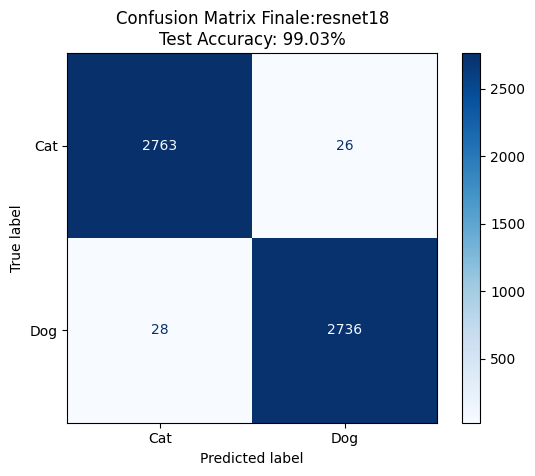

In [ ]:
# test


from pathlib import Path
import torch
# Includiamo confusion_matrix per il grafico e classification_report per le metriche scritte
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report
import matplotlib.pyplot as plt

# Importiamo i moduli personalizzati del tuo progetto Cani/Gatti
#from pet_model import get_model
#from pet_dataset import get_pet_dataloaders

# 1. Configurazione Percorsi e Iperparametri (presi dai tuoi script originali)
base_data_path = '/content'
#base_path = Path(__file__).resolve().parent
model_filepath = "resnet18.pth"
batch_size = 16

# 2. Rilevamento del Dispositivo (Usa la GPU se disponibile, altrimenti CPU)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Dispositivo in uso per il TEST finale: {device}")

# Caricamento del Dataset di Test originale
# Estraiamo il test_loader e la lista dei nomi delle classi ['Cat', 'Dog']
_, test_loader, class_names = get_pet_dataloaders(base_data_path, batch_size)

# Inizializzazione della MobileNetV2 e caricamento dei pesi addestrati
model = get_model("resnet18", num_classes=2).to(device)
print(f"Caricamento dei pesi del modello da: {model_filepath}")
model.load_state_dict(torch.load(model_filepath, map_location=device))

# Impostiamo il modello in modalità valutazione (disattiva Dropout e Batch Normalization)
model.eval()

# Liste per accumulare tutte le predizioni e i target reali
all_preds = []
all_labels = []
correct = 0
total = 0

# Ciclo di Valutazione sul Test Set (senza calcolo del gradiente)
print("Elaborazione delle immagini e calcolo delle previsioni...")
with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)

        # Forward pass (Esecuzione del modello)
        outputs = model(images)
        _, predicted = torch.max(outputs.data, 1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()

        # Accumuliamo i risultati per le metriche di scikit-learn
        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

# Calcolo accuratezza totale
accuracy = 100 * correct / total
print(f'\nAccuratezza complessiva sul Test Set: {accuracy:.2f}%')

# Generazione del Classification Report testuale (Precision, Recall, F1-Score)
print("\n=================== CLASSIFICATION REPORT ===================")
print(classification_report(all_labels, all_preds, target_names=class_names))
print("=============================================================")

# 7. Generazione e Visualizzazione della Matrice di Confusione
cm = confusion_matrix(all_labels, all_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)

# Renderizzazione grafica con la mappa di colore blu ('Blues')
disp.plot(cmap=plt.cm.Blues, values_format='d')
plt.title(f'Confusion Matrix Finale:resnet18\nTest Accuracy: {accuracy:.2f}%')

print("Apertura della finestra del grafico in corso...")
plt.show()

Dispositivo in uso per il TEST finale: cuda
Modello ResNet18 configurato.
-> Pesi caricati con successo dal file: resnet18.pth!
Valutazione in corso sulle immagini modificate al volo...


/usr/local/lib/python3.12/dist-packages/PIL/TiffImagePlugin.py:950: UserWarning: Truncated File Read
  warnings.warn(str(msg))



Accuratezza complessiva sul Test Set STORTO/SCURO: 84.82%

=================== CLASSIFICATION REPORT ===================
              precision    recall  f1-score   support

         Cat       0.79      0.94      0.86      2789
         Dog       0.93      0.75      0.83      2764

    accuracy                           0.85      5553
   macro avg       0.86      0.85      0.85      5553
weighted avg       0.86      0.85      0.85      5553



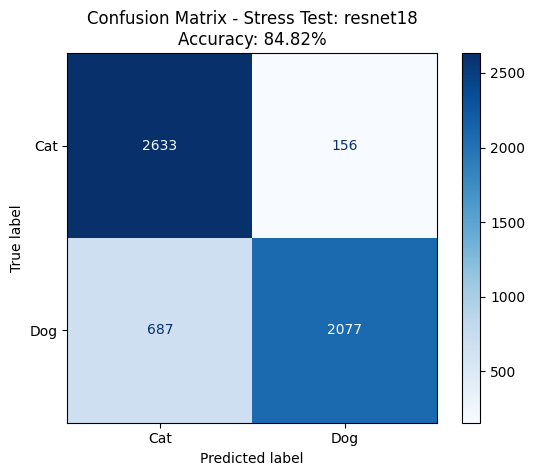

In [ ]:
# Ultima cella: Valutazione Modello Salvato su Test "Sporco"

import torch
import torch.nn as nn
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
from pathlib import Path
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# 1. Configurazione parametri e percorsi
base_data_path = '/content'
batch_size = 32
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Dispositivo in uso per il TEST finale: {device}")

# Scegli quale modello vuoi testare (cambia il nome con il tuo file .pth)
# Es: "resnet18.pth" oppure "mobilenet_v2.pth"
model_path = "resnet18.pth"
model_type = "resnet18" # Metti "resnet18" o "mobilenet_v2" a seconda del file

# DEFINIAMO LA TRASFORMAZIONE STORTA/SCURA PER IL TEST
dirty_test_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomRotation(degrees=(0, 45)),           # Ruota random tra 0 e 45 gradi
    transforms.ColorJitter(brightness=(0.3, 0.7), contrast=(0.4, 0.8)), # Riduce la luminosità a random
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])

# Caricamento del Dataset di Test originale con la trasformazione "dirty"
test_dir = Path(base_data_path) / "test"
test_dataset = datasets.ImageFolder(test_dir, transform=dirty_test_transforms)
test_loader = DataLoader(test_dataset, batch_size=16, shuffle=False)
class_names = test_dataset.classes

# Inizializzazione del modello vuoto
model = get_model(model_type, num_classes=2).to(device)

#  CARICAMENTO DEI PESI TROVATI PRIMA (IL FILE .PTH)
try:
    model.load_state_dict(torch.load(model_path, map_location=device))
    print(f"-> Pesi caricati con successo dal file: {model_path}!")
except FileNotFoundError:
    print(f"ERRORE: Non trovo il file {model_path}. Assicurati che sia caricato su Colab!")

#  ESECUZIONE DEL TEST (Una sola passata sulle immagini storte)
model.eval()
correct = 0
total = 0
all_preds = []
all_labels = []

print("Valutazione in corso sulle immagini modificate al volo...")
with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)

        outputs = model(images)
        _, predicted = torch.max(outputs.data, 1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()

        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

# generazione matrice e report come prima
accuracy = 100 * correct / total
print(f'\n============================================================')
print(f'Accuratezza complessiva sul Test Set STORTO/SCURO: {accuracy:.2f}%')
print(f'============================================================')

print("\n=================== CLASSIFICATION REPORT ===================")
print(classification_report(all_labels, all_preds, target_names=class_names))
print("=============================================================")

cm = confusion_matrix(all_labels, all_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)

disp.plot(cmap=plt.cm.Blues, values_format='d')
plt.title(f'Confusion Matrix - Stress Test: {model_type}\nAccuracy: {accuracy:.2f}%')
plt.show()